# Introduction: Modern Portfolio Theory

**Modern Portfolio Theory (MPT)** is an investment theory that tries to maximize expected return for a given level of risk by carefully choosing the proportion of each asset in a portfolio.

A portfolio is a collection of different investments such as stocks, bonds, commodities, real estate, etc.

Modern Portfolio Theory suggests that the expected return of an investment is directly related to its risk. It suggests that an investor should choose a portfolio based on their risk aversion and investment horizon.

In this notebook we will write Python code to compute the expected return and the volatility (risk) of a portfolio.

We use `yfinance` to fetch market data, `numpy` for the math, `plotly` for the visualizations, and `scipy` for the optimization.

In the rest of this notebook we use the following notation:

- $R_p$: portfolio return
- $w_i$: weight (proportion) of asset $i$ in the portfolio
- $R_i$: return of asset $i$
- $\Sigma_i$: volatility of asset $i$
- $\Sigma_p$: volatility of the portfolio
    - Uppercase variables are random variables
    - Lowercase variables are deterministic
    - Bold variables are vectors
----------

Our goal is to find the weights $w_i$ that maximize the portfolio return for a given level of risk:

$$
\begin{align}
\max_{w_i} \quad & \mathbb{E}[R_p] \\
\text{subject to} \quad & \mathbb{V}[R_p] < \sigma_{max}^2
\end{align}
$$

The portfolio return is defined as the sum of the asset returns weighted by their proportion in the portfolio:

$$
R_p = \sum_i w_i R_i = \mathbf{w}^T \mathbf{R_p}
$$

So the variance of the portfolio is:

$$
\begin{align}
\mathbb{V}[R_p] &= \mathbb{V}[\mathbf{w}^T \mathbf{R_p}] \\
&= \mathbf{w}^T \mathbb{V}[\mathbf{R_p}] \mathbf{w} \\
&= \mathbf{w}^T \mathbf{\Sigma_p} \mathbf{w}
\end{align}
$$

Where $\mathbf{\Sigma_p}$ is the covariance matrix of the asset returns. As a reminder, the covariance matrix is defined as:

$$
\mathbf{\Sigma_p} = \begin{bmatrix}
\mathbb{V}[R_1] & \mathbb{C}[R_1, R_2] & \cdots & \mathbb{C}[R_1, R_n] \\
\mathbb{C}[R_2, R_1] & \mathbb{V}[R_2] & \cdots & \mathbb{C}[R_2, R_n] \\
\vdots & \vdots & \ddots & \vdots \\
\mathbb{C}[R_n, R_1] & \mathbb{C}[R_n, R_2] & \cdots & \mathbb{V}[R_n]
\end{bmatrix}
$$

We still need to define $R_i$ and $\Sigma_i$ for each asset in the portfolio, empirically. Denoting $P_t$ the price of asset $i$ at time $t$, we define the return of asset $i$ as:

$$
R_i = \frac{P_t - P_{t-1}}{P_{t-1}} \text{ and } \Sigma_i = \sqrt{\mathbb{V}[R_i]}
$$

In [1]:
# If a package is missing (e.g. on Google Colab), uncomment the line below:
# %pip install -r requirements.txt

In [2]:
# Imports
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import yfinance as yf
import plotly.graph_objects as go
import plotly.io as pio
import datetime as dt

pio.templates.default = "plotly_white"
# Static (PNG) rendering keeps the charts visible both in Jupyter and on GitHub.
pio.renderers.default = "png"

np.random.seed(42)  # for reproducible Monte Carlo sampling below


## Step 1: Fetching the data

In this step we fetch the data for the assets that make up our portfolio. We consider ten well-known US tech stocks, but feel free to add or remove as many assets as you like.

In [3]:
def get_data(assets, start_date, end_date):
    """
    Downloads daily close prices for a list of tickers from Yahoo Finance.
    yfinance returns prices already adjusted for splits/dividends by default.
    """
    return yf.download(assets, start=start_date, end=end_date, auto_adjust=True)["Close"]

In [4]:
# Assets in the portfolio
assets = ['AAPL', 'AMZN', 'GOOG', 'META', 'NFLX', 'MSFT', 'TSLA', 'NVDA', 'PYPL', 'ADBE']

N = 365 * 2  # two years of historical data

start_date = dt.datetime.now() - dt.timedelta(days=N)
end_date = dt.datetime.now()

data = get_data(assets, start_date, end_date)
data.tail()

[                       0%                       ]

[**********            20%                       ]  2 of 10 completed

[**************        30%                       ]  3 of 10 completed

[**********************50%                       ]  5 of 10 completed

[**********************60%****                   ]  6 of 10 completed

[**********************70%*********              ]  7 of 10 completed

[**********************80%*************          ]  8 of 10 completed

[**********************90%******************     ]  9 of 10 completed

[*********************100%***********************]  10 of 10 completed

Ticker,AAPL,ADBE,AMZN,GOOG,META,MSFT,NFLX,NVDA,PYPL,TSLA
Date,,,,,,,,,,
2026-09-16,332.410004,250.500000,245.960007,339.359985,672.779053,490.299988,76.410004,213.899994,52.709999,358.079987
2026-09-17,337.000000,252.669998,251.190002,343.679993,681.771973,497.750000,75.309998,219.339996,52.939999,366.200012
2026-09-18,336.130005,248.919998,253.710007,344.410004,665.225037,493.779999,71.790001,222.270004,52.410000,364.269989
2026-09-21,338.980011,249.520004,258.450012,350.869995,741.250000,501.609985,73.360001,227.380005,52.619999,375.299988
2026-09-22,339.750000,238.250000,254.979996,347.410004,736.594971,498.000000,72.160004,228.869995,52.889999,378.899994


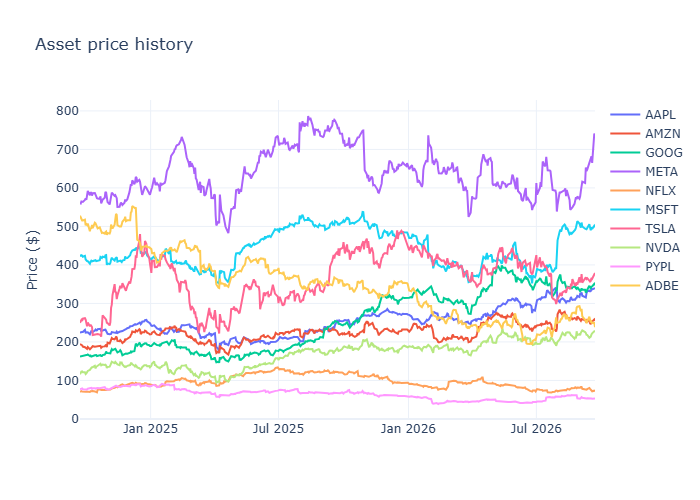

In [5]:
# Overlaying the price history of every asset with plotly
fig = go.Figure()
for a in assets:
    fig.add_trace(go.Scatter(x=data.index, y=data[a], name=a))
fig.update_layout(title='Asset price history', yaxis_title='Price ($)')
fig.show()

As we saw in the lecture, portfolio optimization needs the historical returns of the assets. We fetch two years of data above, which gives us a large enough sample to estimate returns and volatility.

## Step 2: Computing the returns

In this step we compute the daily returns of the stocks. Returns are computed using the following formula:
$$
R_t = \frac{P_{t} - P_{t-1}}{P_{t-1}}
$$
Where $P_{t}$ is the price at time $t$ and $P_{t-1}$ is the price at time $t-1$.
In other words, we compute the percentage change in price between two consecutive days, which is why we divide by $P_{t-1}$.

In [6]:
def compute_portfolio_return(data):
    """
    Returns the daily returns of every asset as a dataframe.
    For example:
    AAPL GOOG MSFT
    0.01 0.02 0.03
    0.02 0.03 0.04
    .... .... ....
    """
    returns = data.pct_change().dropna()
    return returns

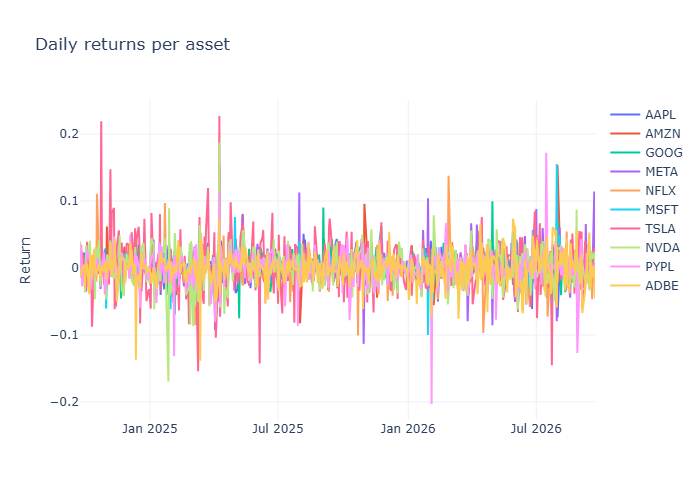

In [7]:
returns = compute_portfolio_return(data)
# Plotting the daily returns
fig = go.Figure()
for a in assets:
    fig.add_trace(go.Scatter(x=returns.index, y=returns[a], name=a))
fig.update_layout(title='Daily returns per asset', yaxis_title='Return')
fig.show()

Here we have access to the realizations of the returns $R_i(\omega)$ and we want to estimate the parameters of the return distribution ($\mu$ and $\sigma$).

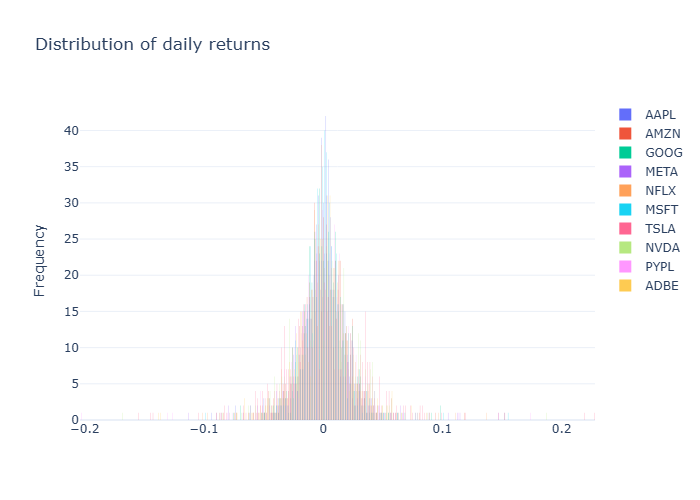

In [8]:
# Returns distribution
fig = go.Figure()
for a in assets:
    fig.add_trace(go.Histogram(x=returns[a], name=a))
fig.update_layout(title='Distribution of daily returns', yaxis_title='Frequency')
fig.show()

We have access to $\mathbb{E}[R_i]$ and $\mathbb{V}[R_i]$. Let's store these values in a dataframe.
We use the following empirical formulas to estimate the parameters of the return distribution:

$$
\begin{align}
\hat{\mu} &= \frac{1}{T} \sum_{t=1}^T R_t \\
\hat{\sigma} &= \sqrt{\frac{1}{T-1} \sum_{t=1}^T (R_t - \hat{\mu})^2}
\end{align}
$$

In [9]:
# Mean return and volatility (std) of every asset
returns_mean = returns.mean()
returns_std = returns.std()

pd.DataFrame({'mean_return': returns_mean, 'volatility': returns_std})

,mean_return,volatility
Ticker,,
AAPL,0.000992,0.018152
ADBE,-0.001311,0.023467
AMZN,0.000774,0.021439
GOOG,0.001721,0.019761
META,0.000843,0.024496
MSFT,0.000472,0.018224
NFLX,0.000286,0.022008
NVDA,0.001749,0.027853
PYPL,-0.000415,0.025467


## Step 3: Covariance matrix

Now that we have the historical returns of the assets, we can compute their covariance matrix. The covariance matrix is defined as:

$$
\mathbf{\Sigma_p} = \begin{bmatrix}
\mathbb{V}[R_1] & \mathbb{C}[R_1, R_2] & \cdots & \mathbb{C}[R_1, R_n] \\
\mathbb{C}[R_2, R_1] & \mathbb{V}[R_2] & \cdots & \mathbb{C}[R_2, R_n] \\
\vdots & \vdots & \ddots & \vdots \\
\mathbb{C}[R_n, R_1] & \mathbb{C}[R_n, R_2] & \cdots & \mathbb{V}[R_n]
\end{bmatrix}
$$

The empirical covariance between two assets $i$ and $j$ is defined as:

$$
\mathbb{C}[R_i, R_j] = \frac{1}{T-1} \sum_{t=1}^T (R_i(t) - \hat{\mu}_i)(R_j(t) - \hat{\mu}_j)
$$

Ticker      AAPL      ADBE      AMZN      GOOG      META      MSFT      NFLX  \
Ticker                                                                         
AAPL    1.000000  0.320959  0.365590  0.343489  0.349336  0.314329  0.252647   
ADBE    0.320959  1.000000  0.296286  0.231032  0.240938  0.387737  0.311699   
AMZN    0.365590  0.296286  1.000000  0.567341  0.554062  0.503934  0.310556   
GOOG    0.343489  0.231032  0.567341  1.000000  0.404300  0.303035  0.217178   
META    0.349336  0.240938  0.554062  0.404300  1.000000  0.376361  0.259111   
MSFT    0.314329  0.387737  0.503934  0.303035  0.376361  1.000000  0.323176   
NFLX    0.252647  0.311699  0.310556  0.217178  0.259111  0.323176  1.000000   
NVDA    0.306161  0.126024  0.427230  0.364920  0.432543  0.420343  0.219688   
PYPL    0.350251  0.397170  0.347568  0.222997  0.321190  0.317797  0.279894   
TSLA    0.373569  0.161761  0.422397  0.453431  0.396230  0.323001  0.205089   

Ticker      NVDA      PYPL      TSLA  


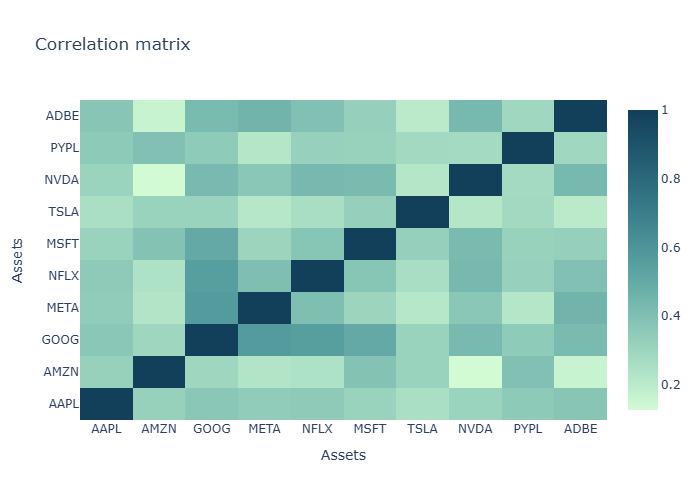

In [10]:
# Covariance and correlation matrices
cov_matrix = returns.cov()
corr_matrix = returns.corr()
print(corr_matrix)

# Displaying the correlation matrix as a heatmap
fig = go.Figure(data=go.Heatmap(z=corr_matrix, x=assets, y=assets, colorscale='Darkmint'))
fig.update_layout(title='Correlation matrix', yaxis_title='Assets', xaxis_title='Assets')
fig.show()

We can now compute the value of our portfolio for different values of $w_i$.

In [11]:
# We create a function that takes a weight vector as input and returns the portfolio's value.
def compute_portfolio_value(weights, returns):
    """
    weights: array of weights
    returns: dataframe of returns
    """
    return np.dot(returns.mean(), weights) * len(returns)

def compute_portfolio_risk(weights, returns):
    """
    weights: array of weights
    returns: dataframe of returns
    """
    return np.sqrt(np.dot(weights.T, np.dot(returns.cov(), weights))) * np.sqrt(len(returns))

w_test = np.array([0.1, 0.2, 0.1, 0.05, 0.05, 0.1, 0.1, 0.1, 0.1, 0.1])  # an arbitrary weight vector (size len(assets), sums to 1)
portfolio_return = compute_portfolio_value(w_test, returns)
portfolio_risk = compute_portfolio_risk(w_test, returns)

initial_portfolio_value = 1000  # initial amount invested ($)

print('Portfolio value: ', np.round((1 + portfolio_return) * initial_portfolio_value), '$')
print('Portfolio risk: ', np.round(portfolio_risk, 4))

Portfolio value:  1203.0 $
Portfolio risk:  0.3385


# Step 4: Portfolio optimization

Now that we have all the information we need, we can start optimizing our portfolio.

$$
\begin{align}
\max_{w_i} \quad & \mathbf{w}^T \mathbf{R_p} \\
\text{subject to} \quad & \mathbf{w}^T \mathbf{\Sigma_p} \mathbf{w} < \sigma_{max}^2
\end{align}
$$

Let's use Monte Carlo simulation to generate random values of $w_i$ and compute the return and the volatility of the portfolio for each value of $w_i$.

In [12]:
def generate_random_weights(n):
    """
    n: number of weights to generate, drawn from a Dirichlet distribution (they sum to 1)
    """
    weights = np.random.dirichlet(np.ones(n), size=1)
    return weights[0]

def generate_random_portfolio(returns):
    """
    returns: dataframe of returns
    """
    weights = generate_random_weights(len(returns.columns))

    portfolio_return = compute_portfolio_value(weights, returns)
    portfolio_risk = compute_portfolio_risk(weights, returns)

    return weights, portfolio_return, portfolio_risk

def generate_random_portfolios(returns, n):
    """
    returns: dataframe of returns
    n: number of portfolios to generate
    """
    portfolios = []
    for i in range(n):
        weights, portfolio_return, portfolio_risk = generate_random_portfolio(returns)
        portfolios.append([weights, portfolio_return, portfolio_risk])
    portfolios_df = pd.DataFrame(portfolios, columns=['weights', 'returns', 'risks'])
    return portfolios_df

In [13]:
# Generating 10,000 random portfolios
N = 10000
portfolios_df = generate_random_portfolios(returns, N)
portfolios_df.head()

,weights,returns,risks
0,"[0.04569442674861943, 0.29310702382574727, 0.1...",0.212918,0.370210
1,"[0.0026099598935592308, 0.43963695788924945, 0...",-0.051120,0.368869
2,"[0.15945316642147045, 0.025312878885099647, 0....",0.342096,0.323729
3,"[0.08215402706741294, 0.01642155191403643, 0.0...",0.446530,0.346550
4,"[0.01931586696535632, 0.10144510717962993, 0.0...",0.410565,0.326762


### Visualizing the results

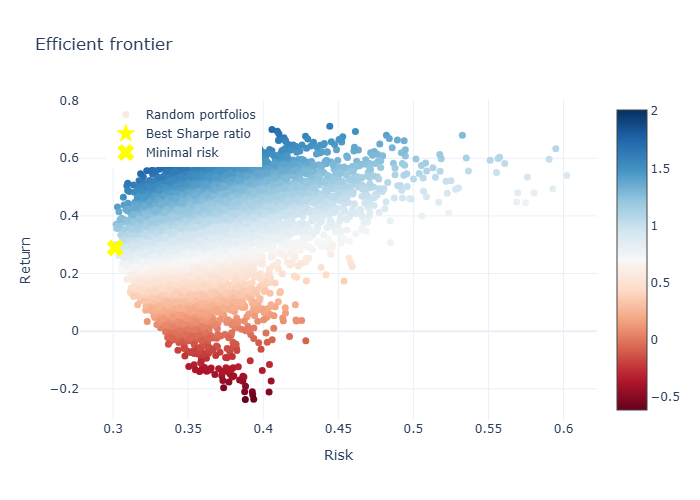

In [14]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=portfolios_df['risks'], y=portfolios_df['returns'], mode='markers', marker=dict(color=portfolios_df['returns']/portfolios_df['risks'], showscale=True, colorscale='RdBu', size=7), name="Random portfolios"))

# Adding a star for the portfolio with the best Sharpe ratio
best_sharpe_ratio_index = (portfolios_df['returns']/portfolios_df['risks']).idxmax()
fig.add_trace(go.Scatter(x=[portfolios_df['risks'][best_sharpe_ratio_index]], y=[portfolios_df['returns'][best_sharpe_ratio_index]], mode='markers', marker=dict(color='yellow', size=15, symbol='star'), name="Best Sharpe ratio"))

# Adding a cross for the portfolio with the lowest risk
lowest_risk_index = portfolios_df['risks'].idxmin()
fig.add_trace(go.Scatter(x=[portfolios_df['risks'][lowest_risk_index]], y=[portfolios_df['returns'][lowest_risk_index]], mode='markers', marker=dict(color='yellow', size=15, symbol='x'), name="Minimal risk"))


fig.update_layout(title='Efficient frontier', yaxis_title='Return', xaxis_title='Risk', legend=dict(yanchor="top", y=1, xanchor="left", x=0.05))
fig.show()

Now that we have computed the return and the volatility of the portfolio for different values of $w_i$, we can pick the value of $w_i$ that maximizes the portfolio return for a given level of risk.

SIGMA_MAX: 0.338
Portfolio value:  1638.0 $


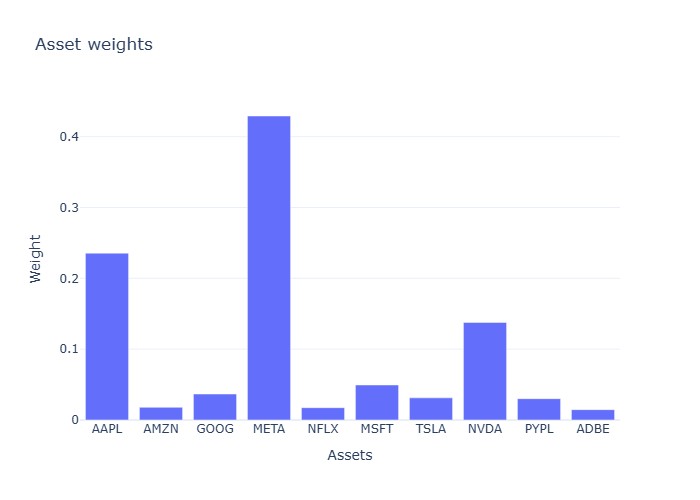

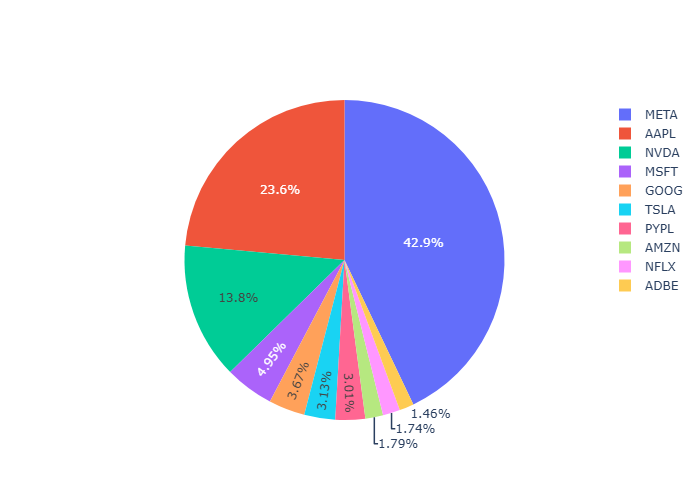

In [15]:
# Maximum tolerated risk: the 25th percentile of the risks observed among the
# random portfolios, so this always keeps a quarter of them as candidates,
# whatever the scale of "risk" happens to be for the chosen assets/period.
SIGMA_MAX = portfolios_df['risks'].quantile(0.25)
print('SIGMA_MAX:', round(SIGMA_MAX, 4))

# The weights that maximize the return for a risk lower than SIGMA_MAX
best_weights_index = portfolios_df[portfolios_df['risks'] < SIGMA_MAX]['returns'].idxmax()
best_weights = portfolios_df['weights'][best_weights_index]

best_portfolio_return = compute_portfolio_value(best_weights, returns)
best_portfolio_risk = compute_portfolio_risk(best_weights, returns)

initial_portfolio_value = 1000

print('Portfolio value: ', np.round((1 + best_portfolio_return) * initial_portfolio_value), '$')

fig = go.Figure()
fig.add_trace(go.Bar(x=assets, y=best_weights))
fig.update_layout(title='Asset weights', yaxis_title='Weight', xaxis_title='Assets')
fig.show()
# Pie chart
fig = go.Figure(data=[go.Pie(labels=assets, values=best_weights)])
fig.show()

### Computing the efficient frontier

In [16]:
def calculate_frontier(returns):
    """
    returns: dataframe of returns
    """
    N = len(returns.columns)
    initial_weights = np.array([1/N]*N)
    bounds = tuple((0, 1) for asset in range(N))
    frontier_risks = []
    frontier_returns = []
    frontier_weights = []
    lowest_risk_index = portfolios_df['risks'].idxmin()
    min_return = portfolios_df['returns'][lowest_risk_index]
    for portfolio_return in np.linspace(min_return, 1, 100):
        constraints = ({'type': 'eq', 'fun': lambda x: compute_portfolio_value(x, returns) - portfolio_return},
                       {'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
        efficient_portfolio = minimize(compute_portfolio_risk, initial_weights, args=returns, method='SLSQP', bounds=bounds, constraints=constraints)
        frontier_risks.append(efficient_portfolio.fun)
        frontier_returns.append(portfolio_return)
        frontier_weights = efficient_portfolio.x
    return frontier_risks, frontier_returns, frontier_weights

frontier_risks, frontier_returns, w = calculate_frontier(returns)

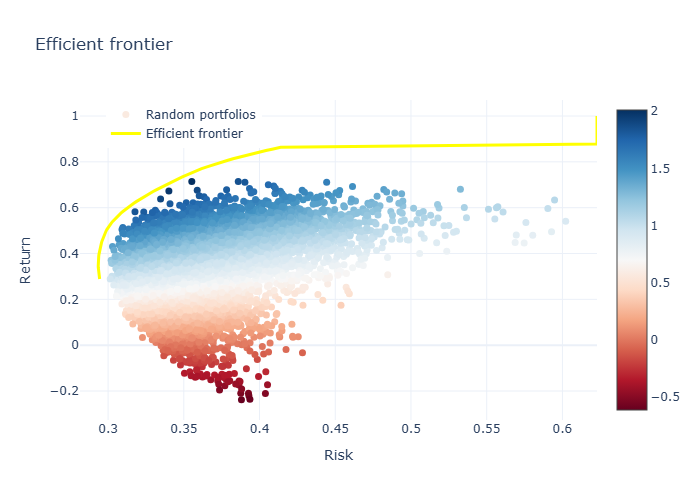

In [17]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=portfolios_df['risks'], y=portfolios_df['returns'], mode='markers', marker=dict(color=portfolios_df['returns']/portfolios_df['risks'], showscale=True, colorscale='RdBu', size=7), name="Random portfolios"))
fig.add_trace(go.Scatter(x=frontier_risks, y=frontier_returns, mode='lines', line=dict(color='yellow', width=3), name='Efficient frontier'))
fig.update_layout(title='Efficient frontier', yaxis_title='Return', xaxis_title='Risk', legend=dict(yanchor="top", y=1, xanchor="left", x=0.05))
fig.show()

Given $\sigma_{max}$, we can compute the portfolio's maximum return using the efficient frontier.

# Step 5: Testing an investment strategy

Let's define a simple investment strategy:

- Every $N$ days, we rebalance our portfolio by choosing the weights $w_i$ that maximize the portfolio return for a given level of risk, using the data of the previous $N$ days.
- We start by investing $S$ in our portfolio.

We now test this investment strategy over a period of about a year and a half.

Here, $S = 1000$, $N = 30$, and at each rebalancing we tolerate the risk of the least risky quarter of the sampled portfolios (see below).

### Simulating the investment strategy

In [18]:
S = 1000            # initial amount invested ($)
N = 30               # rebalancing frequency, in days
SIGMA_MAX_QUANTILE = 0.25  # tolerate the risk of the least risky quarter of sampled portfolios

number_of_iteration_to_test = 15  # number of rebalancing periods to simulate

portfolio_value_history = []
portfolio_value_history_without_rebalancing = []
s = S
portfolio_weights_history = []

first_date = dt.datetime.now() - dt.timedelta(days=200+365)
current_date = dt.datetime.now() - dt.timedelta(days=200)
total_data = get_data(assets, first_date, dt.datetime.now())

random_fix_weights = generate_random_weights(len(assets))

for i in range(number_of_iteration_to_test):
    print('Simulation: ', i)
    # We fetch the data of the last N days
    current_data = total_data[first_date:current_date]

    next_data = total_data[current_date:current_date + dt.timedelta(days=N)]
    # We compute the returns
    past_returns = compute_portfolio_return(current_data)
    next_returns = compute_portfolio_return(next_data)

    portfolios_df = generate_random_portfolios(past_returns, 10000)
    sigma_max = portfolios_df['risks'].quantile(SIGMA_MAX_QUANTILE)

    # The weights that maximize the return for a risk lower than sigma_max
    best_weights_index = portfolios_df[portfolios_df['risks'] < sigma_max]['returns'].idxmax()
    best_weights = portfolios_df['weights'][best_weights_index]

    # We compute the portfolio's return
    portfolio_return = compute_portfolio_value(best_weights, next_returns)
    portfolio_return_without_rebalancing = compute_portfolio_value(random_fix_weights, next_returns)

    S = (1+portfolio_return) * S
    s = (1+portfolio_return_without_rebalancing) * s

    portfolio_value_history.append(S)
    portfolio_value_history_without_rebalancing.append(s)
    portfolio_weights_history.append(best_weights)

    current_date += dt.timedelta(days=N)

[                       0%                       ]

[**********            20%                       ]  2 of 10 completed

[**********            20%                       ]  2 of 10 completed

[*******************   40%                       ]  4 of 10 completed

[**********************50%                       ]  5 of 10 completed

...

Simulation:  10


Simulation:  11


Simulation:  12


Simulation:  13


Simulation:  14


In [19]:
# Sharpe ratio of the rebalancing strategy
strategy_returns = pd.Series(portfolio_value_history).pct_change().dropna()
sharpe_ratio = np.sqrt(252 / N) * strategy_returns.mean() / strategy_returns.std()
print('Sharpe ratio of the rebalancing strategy: ', np.round(sharpe_ratio, 3))

Sharpe ratio of the rebalancing strategy:  1.258


### Portfolio value over time

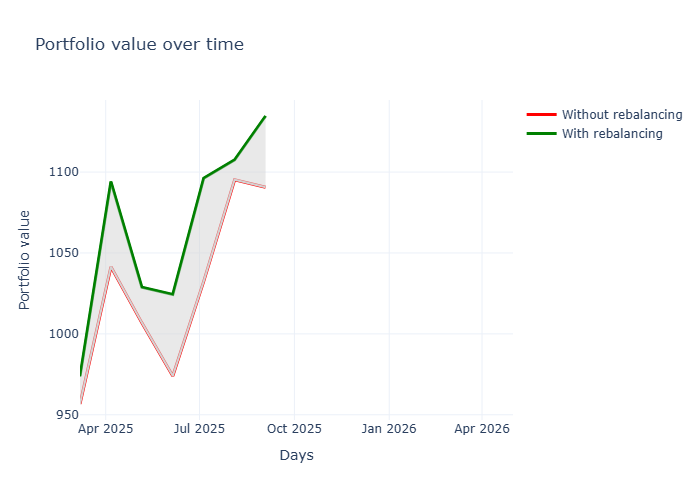

In [20]:
# Plotting the portfolio value history, with and without rebalancing
fig = go.Figure()
fig.add_trace(go.Scatter(x=[first_date + dt.timedelta(i*N) for i in range(len(portfolio_value_history_without_rebalancing))], y=portfolio_value_history, mode='lines', line=dict(color='green', width=3), name='With rebalancing'))
fig.add_trace(go.Scatter(x=[first_date + dt.timedelta(i*N) for i in range(len(portfolio_value_history_without_rebalancing))], y=portfolio_value_history_without_rebalancing, mode='lines', line=dict(color='red', width=3), name='Without rebalancing'))
fig.update_layout(title='Portfolio value over time', yaxis_title='Portfolio value', xaxis_title='Days')
# Shading the area between the two lines
fig.add_trace(go.Scatter(
    x=[first_date + dt.timedelta(i*N) for i in range(len(portfolio_value_history_without_rebalancing))],
    y=portfolio_value_history,
    fill=None,
    mode='lines',
    line_color='green',
    showlegend=False))
fig.add_trace(go.Scatter(
    x=[first_date + dt.timedelta(i*N) for i in range(len(portfolio_value_history_without_rebalancing))],
    y=portfolio_value_history_without_rebalancing,
    fill='tonexty',
    mode='lines',
    line_color='lightgrey',
    showlegend=False))

fig.show()

### Evolution of the asset weights in the portfolio

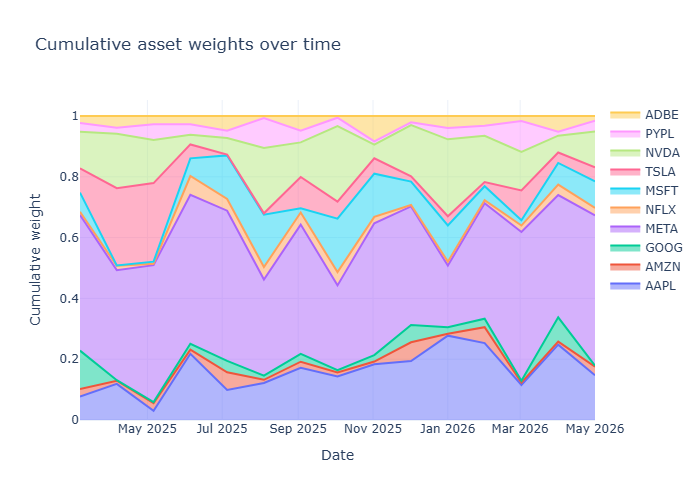

In [21]:
weights_df = pd.DataFrame(portfolio_weights_history, columns=[assets[i] for i in range(len(assets))])

cumulative_weights = weights_df.cumsum(axis=1)

fig = go.Figure()
for column in cumulative_weights.columns:
    fig.add_trace(go.Scatter(
        x=[first_date + dt.timedelta(i*N) for i in cumulative_weights.index],
        y=cumulative_weights[column],
        fill='tonexty',
        mode='lines',
        name=column
    ))

fig.update_layout(
    title='Cumulative asset weights over time',
    yaxis_title='Cumulative weight',
    xaxis_title='Date'
)
fig.show()

## Conclusion

We built a simple Modern Portfolio Theory pipeline end to end: fetching prices, estimating returns and covariances, sampling random portfolios to trace the efficient frontier, and backtesting a periodic-rebalancing strategy against a static one. The rebalancing strategy is naive (no transaction costs, no risk-free asset, short lookback window) but it illustrates the core mechanics behind mean-variance optimization.